In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import time

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
torch.manual_seed(42)
np.random.seed(42)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(42)

CLASSES = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
           'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']
print(f"Using device: {device}")

Using device: cuda


In [3]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])


full_train = datasets.FashionMNIST('./data', train=True, download=True, transform=transform)
test_ds = datasets.FashionMNIST('./data', train=False, download=True, transform=transform)


train_size = 54000
val_size = 6000
train_ds, val_ds = random_split(full_train, [train_size, val_size],
                                 generator=torch.Generator().manual_seed(42))

train_loader = DataLoader(train_ds, batch_size=64, shuffle=True, num_workers=2)
val_loader = DataLoader(val_ds, batch_size=256, num_workers=2)
test_loader = DataLoader(test_ds, batch_size=256, num_workers=2)

print(f"Train: {len(train_ds)}, Val: {len(val_ds)}, Test: {len(test_ds)}")


x_sample, y_sample = next(iter(train_loader))
print(f"Batch shape: {x_sample.shape}, Labels shape: {y_sample.shape}")
print(f"Pixel range: [{x_sample.min():.2f}, {x_sample.max():.2f}]")

100%|██████████| 26.4M/26.4M [00:01<00:00, 14.3MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 212kB/s]
100%|██████████| 4.42M/4.42M [00:01<00:00, 3.94MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 10.1MB/s]

Train: 54000, Val: 6000, Test: 10000


Batch shape: torch.Size([64, 1, 28, 28]), Labels shape: torch.Size([64])
Pixel range: [-1.00, 1.00]


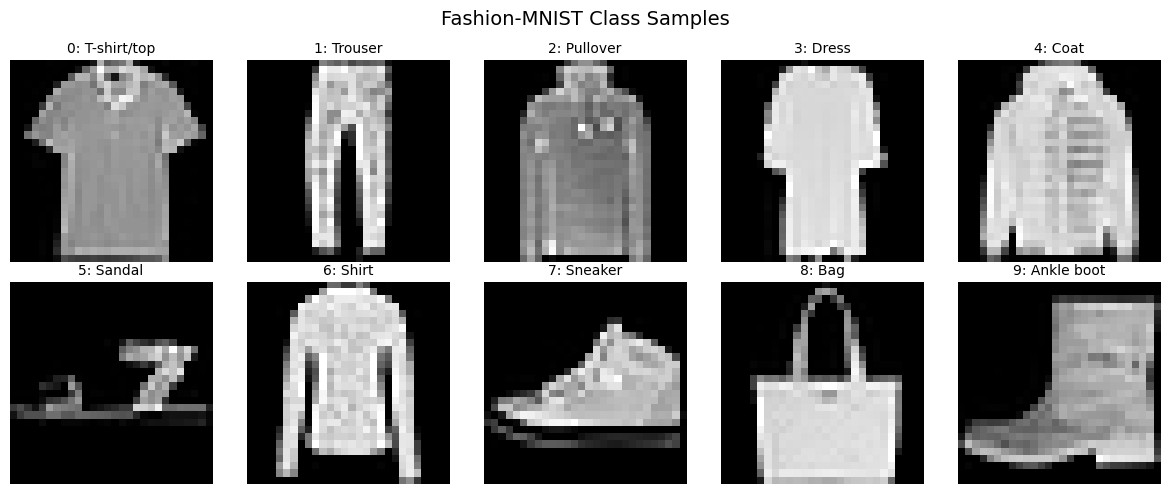

In [4]:
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
for i, ax in enumerate(axes.flat):

    for img, label in train_ds:
        if label == i:
            ax.imshow(img.squeeze() * 0.5 + 0.5, cmap='gray')
            ax.set_title(f'{i}: {CLASSES[i]}', fontsize=10)
            ax.axis('off')
            break
plt.suptitle('Fashion-MNIST Class Samples', fontsize=14)
plt.tight_layout()
plt.savefig('class_samples.png', dpi=150, bbox_inches='tight')
plt.show()

In [5]:
class MLP(nn.Module):
    """Baseline: 2 hidden FC layers. ~109k params."""
    def __init__(self, activation=nn.ReLU):
        super().__init__()
        self.net = nn.Sequential(
            nn.Flatten(),
            nn.Linear(28*28, 128),
            activation(),
            nn.Dropout(0.2),
            nn.Linear(128, 64),
            activation(),
            nn.Linear(64, 10),
        )
    def forward(self, x):
        return self.net(x)


class CNN(nn.Module):
    """LeNet-style: 2 conv-pool + 2 FC. ~421k params."""
    def __init__(self, activation=nn.ReLU):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, padding=1),
            activation(),
            nn.MaxPool2d(2),
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            activation(),
            nn.MaxPool2d(2),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64*7*7, 128),
            activation(),
            nn.Dropout(0.3),
            nn.Linear(128, 10),
        )
    def forward(self, x):
        return self.classifier(self.features(x))



def count_params(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

mlp_test = MLP()
cnn_test = CNN()
print(f"MLP parameters: {count_params(mlp_test):,}")
print(f"CNN parameters: {count_params(cnn_test):,}")


mlp_test = mlp_test.to(device)
cnn_test = cnn_test.to(device)
x_sample = x_sample.to(device)
print(f"MLP output shape: {mlp_test(x_sample).shape}")
print(f"CNN output shape: {cnn_test(x_sample).shape}")

MLP parameters: 109,386
CNN parameters: 421,642
MLP output shape: torch.Size([64, 10])
CNN output shape: torch.Size([64, 10])


In [6]:
def train_model(model, label, epochs=15, lr=1e-3, patience=3):
    model = model.to(device)
    optimizer = optim.Adam(model.parameters(), lr=lr)
    criterion = nn.CrossEntropyLoss()

    history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}
    best_acc, no_improve = 0.0, 0
    start = time.time()

    for epoch in range(epochs):
        # --- Train ---
        model.train()
        total_loss, correct, total = 0.0, 0, 0
        for x, y in train_loader:
            x, y = x.to(device), y.to(device)
            optimizer.zero_grad()
            out = model(x)
            loss = criterion(out, y)
            loss.backward()
            optimizer.step()
            total_loss += loss.item() * x.size(0)
            correct += (out.argmax(1) == y).sum().item()
            total += y.size(0)
        train_loss = total_loss / total
        train_acc = correct / total

        # --- Validation ---
        model.eval()
        val_loss, val_correct, val_total = 0.0, 0, 0
        with torch.no_grad():
            for x, y in val_loader:
                x, y = x.to(device), y.to(device)
                out = model(x)
                val_loss += criterion(out, y).item() * x.size(0)
                val_correct += (out.argmax(1) == y).sum().item()
                val_total += y.size(0)
        val_loss /= val_total
        val_acc = val_correct / val_total

        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        history['train_acc'].append(train_acc)
        history['val_acc'].append(val_acc)

        print(f"[{label}] Epoch {epoch+1:2d}/{epochs}  "
              f"train_loss={train_loss:.4f} train_acc={train_acc:.4f}  "
              f"val_loss={val_loss:.4f} val_acc={val_acc:.4f}")

        # Early stopping
        if val_acc > best_acc:
            best_acc = val_acc
            no_improve = 0
            torch.save(model.state_dict(), f'best_{label}.pth')
        else:
            no_improve += 1
            if no_improve >= patience:
                print(f"[{label}] Early stopping at epoch {epoch+1}")
                break

    elapsed = time.time() - start
    print(f"[{label}] Training time: {elapsed:.1f}s, Best val acc: {best_acc:.4f}\n")
    return history, best_acc, elapsed

In [7]:
results = {}

# 1. MLP baseline
print("=" * 60)
print("MLP BASELINE")
print("=" * 60)
h, acc, t = train_model(MLP(nn.ReLU), 'MLP', epochs=15)
results['MLP'] = {'history': h, 'best_acc': acc, 'time': t}

# 2. CNN with ReLU (ana model)
print("=" * 60)
print("CNN with ReLU")
print("=" * 60)
h, acc, t = train_model(CNN(nn.ReLU), 'CNN_ReLU', epochs=15)
results['CNN-ReLU'] = {'history': h, 'best_acc': acc, 'time': t}

# 3. CNN with Tanh
print("=" * 60)
print("CNN with Tanh")
print("=" * 60)
h, acc, t = train_model(CNN(nn.Tanh), 'CNN_Tanh', epochs=15)
results['CNN-Tanh'] = {'history': h, 'best_acc': acc, 'time': t}

# 4. CNN with Sigmoid (gradient vanishing demo)
print("=" * 60)
print("CNN with Sigmoid")
print("=" * 60)
h, acc, t = train_model(CNN(nn.Sigmoid), 'CNN_Sigmoid', epochs=15)
results['CNN-Sigmoid'] = {'history': h, 'best_acc': acc, 'time': t}

# Özet tablo
print("\n" + "=" * 60)
print("FINAL RESULTS")
print("=" * 60)
print(f"{'Model':<20} {'Val Acc':<12} {'Time (s)':<12}")
print("-" * 60)
for name, r in results.items():
    print(f"{name:<20} {r['best_acc']:.4f}      {r['time']:.1f}")

MLP BASELINE
[MLP] Epoch  1/15  train_loss=0.5563 train_acc=0.7976  val_loss=0.4241 val_acc=0.8488
[MLP] Epoch  2/15  train_loss=0.4135 train_acc=0.8505  val_loss=0.4006 val_acc=0.8553
[MLP] Epoch  3/15  train_loss=0.3781 train_acc=0.8626  val_loss=0.3777 val_acc=0.8597
[MLP] Epoch  4/15  train_loss=0.3554 train_acc=0.8693  val_loss=0.3675 val_acc=0.8707
[MLP] Epoch  5/15  train_loss=0.3378 train_acc=0.8762  val_loss=0.3517 val_acc=0.8745
[MLP] Epoch  6/15  train_loss=0.3273 train_acc=0.8799  val_loss=0.3367 val_acc=0.8800
[MLP] Epoch  7/15  train_loss=0.3147 train_acc=0.8834  val_loss=0.3446 val_acc=0.8777
[MLP] Epoch  8/15  train_loss=0.3059 train_acc=0.8865  val_loss=0.3370 val_acc=0.8788
[MLP] Epoch  9/15  train_loss=0.2972 train_acc=0.8889  val_loss=0.3229 val_acc=0.8815
[MLP] Epoch 10/15  train_loss=0.2894 train_acc=0.8930  val_loss=0.3290 val_acc=0.8823
[MLP] Epoch 11/15  train_loss=0.2859 train_acc=0.8937  val_loss=0.3218 val_acc=0.8862
[MLP] Epoch 12/15  train_loss=0.2762 trai

Best model: CNN-Tanh (val acc: 0.9247)

Test accuracy: 0.9183



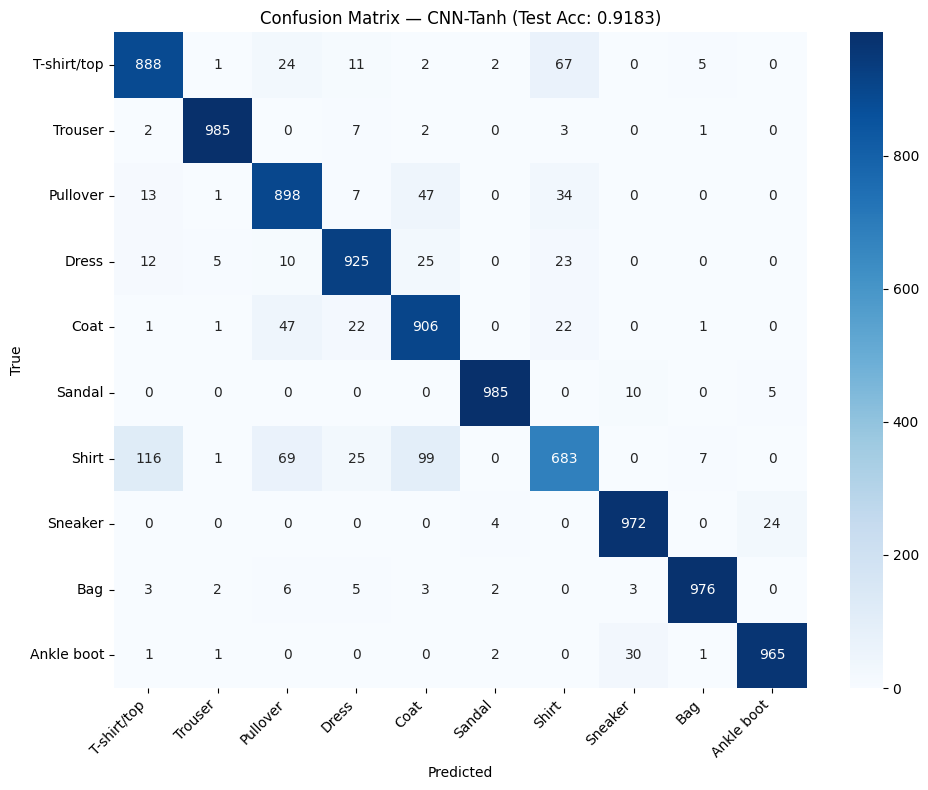

              precision    recall  f1-score   support

 T-shirt/top     0.8571    0.8880    0.8723      1000
     Trouser     0.9880    0.9850    0.9865      1000
    Pullover     0.8520    0.8980    0.8744      1000
       Dress     0.9232    0.9250    0.9241      1000
        Coat     0.8358    0.9060    0.8695      1000
      Sandal     0.9899    0.9850    0.9875      1000
       Shirt     0.8209    0.6830    0.7456      1000
     Sneaker     0.9576    0.9720    0.9648      1000
         Bag     0.9849    0.9760    0.9804      1000
  Ankle boot     0.9708    0.9650    0.9679      1000

    accuracy                         0.9183     10000
   macro avg     0.9180    0.9183    0.9173     10000
weighted avg     0.9180    0.9183    0.9173     10000



In [8]:
# En iyi modeli yükle
best_name = max(results, key=lambda k: results[k]['best_acc'])
print(f"Best model: {best_name} (val acc: {results[best_name]['best_acc']:.4f})")

if 'MLP' in best_name:
    best_model = MLP(nn.ReLU)
    state_path = 'best_MLP.pth'
else:
    act = {'ReLU': nn.ReLU, 'Tanh': nn.Tanh, 'Sigmoid': nn.Sigmoid}[best_name.split('-')[1]]
    best_model = CNN(act)
    state_path = f'best_CNN_{best_name.split("-")[1]}.pth'

best_model.load_state_dict(torch.load(state_path))
best_model = best_model.to(device)
best_model.eval()

# Test evaluation
all_pred, all_true = [], []
with torch.no_grad():
    for x, y in test_loader:
        x = x.to(device)
        pred = best_model(x).argmax(1).cpu()
        all_pred.append(pred); all_true.append(y)
all_pred = torch.cat(all_pred).numpy()
all_true = torch.cat(all_true).numpy()
test_acc = (all_pred == all_true).mean()
print(f"\nTest accuracy: {test_acc:.4f}\n")

# Confusion matrix
cm = confusion_matrix(all_true, all_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=CLASSES, yticklabels=CLASSES, cbar=True)
plt.xlabel('Predicted'); plt.ylabel('True')
plt.title(f'Confusion Matrix — {best_name} (Test Acc: {test_acc:.4f})')
plt.xticks(rotation=45, ha='right'); plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

# Per-class report
print(classification_report(all_true, all_pred, target_names=CLASSES, digits=4))

In [9]:
from google.colab import files
import os

files_to_download = [
    'class_samples.png',
    'training_curves.png',
    'accuracy_comparison.png',
    'confusion_matrix.png',
    'best_CNN_ReLU.pth',
]
for f in files_to_download:
    if os.path.exists(f):
        files.download(f)
        print(f"Downloaded: {f}")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Downloaded: class_samples.png


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Downloaded: confusion_matrix.png


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Downloaded: best_CNN_ReLU.pth


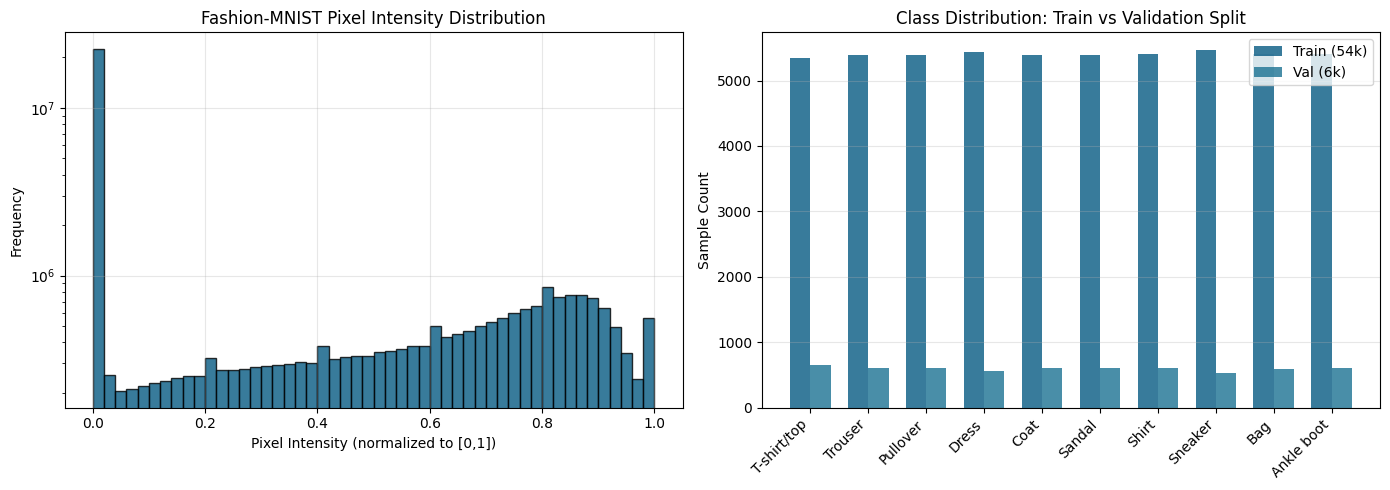


Pixel statistics (normalized [-1, 1]):
  Mean: -0.4287
  Std:  0.7056
  Min:  -1.0000
  Max:  1.0000

Dataset-specific normalization stats (would-be mean/std in [0,1]):
  Empirical mean: 0.2856
  Empirical std:  0.3528
  Used in project: mean=0.5, std=0.5 (approximation)

Class distribution in validation set:
  T-shirt/top     train= 5342, val= 658
  Trouser         train= 5389, val= 611
  Pullover        train= 5388, val= 612
  Dress           train= 5438, val= 562
  Coat            train= 5393, val= 607
  Sandal          train= 5387, val= 613
  Shirt           train= 5400, val= 600
  Sneaker         train= 5463, val= 537
  Bag             train= 5402, val= 598
  Ankle boot      train= 5398, val= 602


In [10]:
# Pixel intensity histogram + class distribution analysis
import matplotlib.pyplot as plt
import numpy as np
from collections import Counter

# Pixel intensity histogram (training set)
all_pixels = []
for img, _ in train_ds:
    all_pixels.append(img.numpy().flatten())
all_pixels = np.concatenate(all_pixels)

# Denormalize to [0, 1] for interpretability
all_pixels_01 = (all_pixels * 0.5) + 0.5

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: pixel intensity histogram
axes[0].hist(all_pixels_01, bins=50, color='#065A82', alpha=0.8, edgecolor='black')
axes[0].set_xlabel('Pixel Intensity (normalized to [0,1])')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Fashion-MNIST Pixel Intensity Distribution')
axes[0].set_yscale('log')
axes[0].grid(alpha=0.3)

# Right: class distribution in train/val
train_labels = [label for _, label in train_ds]
val_labels = [label for _, label in val_ds]
train_counts = Counter(train_labels)
val_counts = Counter(val_labels)

x = np.arange(10)
width = 0.35
axes[1].bar(x - width/2, [train_counts[i] for i in range(10)], width,
            label='Train (54k)', color='#065A82', alpha=0.8)
axes[1].bar(x + width/2, [val_counts[i] for i in range(10)], width,
            label='Val (6k)', color='#1C7293', alpha=0.8)
axes[1].set_xticks(x)
axes[1].set_xticklabels(CLASSES, rotation=45, ha='right')
axes[1].set_ylabel('Sample Count')
axes[1].set_title('Class Distribution: Train vs Validation Split')
axes[1].legend()
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('preprocessing_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

# Print stats
print(f"\nPixel statistics (normalized [-1, 1]):")
print(f"  Mean: {all_pixels.mean():.4f}")
print(f"  Std:  {all_pixels.std():.4f}")
print(f"  Min:  {all_pixels.min():.4f}")
print(f"  Max:  {all_pixels.max():.4f}")

print(f"\nDataset-specific normalization stats (would-be mean/std in [0,1]):")
mean_raw = all_pixels_01.mean()
std_raw = all_pixels_01.std()
print(f"  Empirical mean: {mean_raw:.4f}")
print(f"  Empirical std:  {std_raw:.4f}")
print(f"  Used in project: mean=0.5, std=0.5 (approximation)")

print(f"\nClass distribution in validation set:")
for i in range(10):
    print(f"  {CLASSES[i]:<15} train={train_counts[i]:>5}, val={val_counts[i]:>4}")

In [11]:
# Tüm 4 model için test accuracy hesapla
print("=" * 60)
print("TEST SET EVALUATION FOR ALL MODELS")
print("=" * 60)

test_results = {}

model_configs = [
    ('MLP', MLP, nn.ReLU, 'best_MLP.pth'),
    ('CNN-ReLU', CNN, nn.ReLU, 'best_CNN_ReLU.pth'),
    ('CNN-Tanh', CNN, nn.Tanh, 'best_CNN_Tanh.pth'),
    ('CNN-Sigmoid', CNN, nn.Sigmoid, 'best_CNN_Sigmoid.pth'),
]

for name, model_class, act, path in model_configs:
    model = model_class(act).to(device)
    model.load_state_dict(torch.load(path))
    model.eval()

    correct, total = 0, 0
    with torch.no_grad():
        for x, y in test_loader:
            x, y = x.to(device), y.to(device)
            pred = model(x).argmax(1)
            correct += (pred == y).sum().item()
            total += y.size(0)
    test_acc = correct / total
    test_results[name] = test_acc
    print(f"{name:<15} val_acc={results[name]['best_acc']:.4f}  test_acc={test_acc:.4f}  gap={results[name]['best_acc']-test_acc:+.4f}")

print("\n--- Summary ---")
print(f"{'Model':<15} {'Val Acc':<12} {'Test Acc':<12} {'Gap':<10}")
print("-" * 60)
for name in test_results:
    val = results[name]['best_acc']
    test = test_results[name]
    print(f"{name:<15} {val:.4f}      {test:.4f}      {val-test:+.4f}")

TEST SET EVALUATION FOR ALL MODELS
MLP             val_acc=0.8870  test_acc=0.8795  gap=+0.0075
CNN-ReLU        val_acc=0.9202  test_acc=0.9132  gap=+0.0070
CNN-Tanh        val_acc=0.9247  test_acc=0.9183  gap=+0.0064
CNN-Sigmoid     val_acc=0.9032  test_acc=0.9012  gap=+0.0020

--- Summary ---
Model           Val Acc      Test Acc     Gap       
------------------------------------------------------------
MLP             0.8870      0.8795      +0.0075
CNN-ReLU        0.9202      0.9132      +0.0070
CNN-Tanh        0.9247      0.9183      +0.0064
CNN-Sigmoid     0.9032      0.9012      +0.0020


In [12]:
# 3 farklı seed ile CNN-ReLU train et — varyans için
print("=" * 60)
print("REPRODUCIBILITY: CNN-ReLU with 3 different seeds")
print("=" * 60)

seed_results = {}
seeds_to_test = [42, 123, 7]

for seed in seeds_to_test:
    print(f"\n--- Seed {seed} ---")

    # Set ALL seeds for reproducibility
    torch.manual_seed(seed)
    np.random.seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

    # Re-split data with this seed (use new generator)
    train_ds_seed, val_ds_seed = random_split(
        full_train, [54000, 6000],
        generator=torch.Generator().manual_seed(seed)
    )
    train_loader_seed = DataLoader(train_ds_seed, batch_size=64, shuffle=True, num_workers=2)
    val_loader_seed = DataLoader(val_ds_seed, batch_size=256, num_workers=2)

    # Train CNN-ReLU with this seed
    model = CNN(nn.ReLU).to(device)
    optimizer = optim.Adam(model.parameters(), lr=1e-3)
    criterion = nn.CrossEntropyLoss()

    best_val_acc = 0.0
    no_improve = 0
    start = time.time()

    for epoch in range(15):
        model.train()
        for x, y in train_loader_seed:
            x, y = x.to(device), y.to(device)
            optimizer.zero_grad()
            loss = criterion(model(x), y)
            loss.backward()
            optimizer.step()

        model.eval()
        correct, total = 0, 0
        with torch.no_grad():
            for x, y in val_loader_seed:
                x, y = x.to(device), y.to(device)
                correct += (model(x).argmax(1) == y).sum().item()
                total += y.size(0)
        val_acc = correct / total

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            no_improve = 0
        else:
            no_improve += 1
            if no_improve >= 3:
                print(f"  Early stop at epoch {epoch+1}, best val_acc={best_val_acc:.4f}")
                break

    # Test set evaluation
    model.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for x, y in test_loader:
            x, y = x.to(device), y.to(device)
            correct += (model(x).argmax(1) == y).sum().item()
            total += y.size(0)
    test_acc = correct / total

    elapsed = time.time() - start
    seed_results[seed] = {'val_acc': best_val_acc, 'test_acc': test_acc, 'time': elapsed}
    print(f"  Seed {seed}: val={best_val_acc:.4f}, test={test_acc:.4f}, time={elapsed:.1f}s")

# Summary statistics
print("\n" + "=" * 60)
print("REPRODUCIBILITY SUMMARY (CNN-ReLU)")
print("=" * 60)
val_accs = [r['val_acc'] for r in seed_results.values()]
test_accs = [r['test_acc'] for r in seed_results.values()]
print(f"Validation Accuracy: {np.mean(val_accs):.4f} ± {np.std(val_accs):.4f}")
print(f"Test Accuracy:       {np.mean(test_accs):.4f} ± {np.std(test_accs):.4f}")
print(f"\nIndividual runs:")
for seed, r in seed_results.items():
    print(f"  Seed {seed}: val={r['val_acc']:.4f}, test={r['test_acc']:.4f}")

# Reset to default seed for next experiments
torch.manual_seed(42)
np.random.seed(42)
torch.cuda.manual_seed_all(42)

REPRODUCIBILITY: CNN-ReLU with 3 different seeds

--- Seed 42 ---
  Seed 42: val=0.9278, test=0.9203, time=237.2s

--- Seed 123 ---
  Early stop at epoch 11, best val_acc=0.9218
  Seed 123: val=0.9218, test=0.9178, time=170.5s

--- Seed 7 ---
  Early stop at epoch 12, best val_acc=0.9273
  Seed 7: val=0.9273, test=0.9162, time=186.6s

REPRODUCIBILITY SUMMARY (CNN-ReLU)
Validation Accuracy: 0.9257 ± 0.0027
Test Accuracy:       0.9181 ± 0.0017

Individual runs:
  Seed 42: val=0.9278, test=0.9203
  Seed 123: val=0.9218, test=0.9178
  Seed 7: val=0.9273, test=0.9162


In [13]:
# Augmentation ile CNN-ReLU train et
print("=" * 60)
print("DATA AUGMENTATION EXPERIMENT")
print("=" * 60)

# Augmented transform
augment_transform = transforms.Compose([
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(10),
    transforms.RandomAffine(0, translate=(0.05, 0.05)),
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

# Standard transform (val/test için, augmentation yok)
standard_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

# Augmented dataset (training only)
full_train_aug = datasets.FashionMNIST('./data', train=True, download=False, transform=augment_transform)
train_ds_aug, _ = random_split(full_train_aug, [54000, 6000],
                                generator=torch.Generator().manual_seed(42))
train_loader_aug = DataLoader(train_ds_aug, batch_size=64, shuffle=True, num_workers=2)

# Reset seed for fair comparison
torch.manual_seed(42)
np.random.seed(42)
torch.cuda.manual_seed_all(42)

# Train CNN-ReLU with augmentation
print("Training CNN-ReLU with augmentation (15 epochs max)...")
model_aug = CNN(nn.ReLU).to(device)
optimizer = optim.Adam(model_aug.parameters(), lr=1e-3)
criterion = nn.CrossEntropyLoss()

best_val_acc_aug = 0.0
no_improve = 0
start = time.time()

for epoch in range(15):
    model_aug.train()
    for x, y in train_loader_aug:
        x, y = x.to(device), y.to(device)
        optimizer.zero_grad()
        loss = criterion(model_aug(x), y)
        loss.backward()
        optimizer.step()

    model_aug.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for x, y in val_loader:
            x, y = x.to(device), y.to(device)
            correct += (model_aug(x).argmax(1) == y).sum().item()
            total += y.size(0)
    val_acc = correct / total
    print(f"  Epoch {epoch+1}: val_acc={val_acc:.4f}")

    if val_acc > best_val_acc_aug:
        best_val_acc_aug = val_acc
        no_improve = 0
        torch.save(model_aug.state_dict(), 'best_CNN_ReLU_aug.pth')
    else:
        no_improve += 1
        if no_improve >= 3:
            print(f"  Early stop at epoch {epoch+1}")
            break

# Test evaluation
model_aug.load_state_dict(torch.load('best_CNN_ReLU_aug.pth'))
model_aug.eval()
correct, total = 0, 0
class_correct = np.zeros(10)
class_total = np.zeros(10)
with torch.no_grad():
    for x, y in test_loader:
        x, y = x.to(device), y.to(device)
        pred = model_aug(x).argmax(1)
        correct += (pred == y).sum().item()
        total += y.size(0)
        for c in range(10):
            mask = (y == c)
            class_correct[c] += (pred[mask] == c).sum().item()
            class_total[c] += mask.sum().item()

test_acc_aug = correct / total
elapsed = time.time() - start

print(f"\n--- Augmentation Results ---")
print(f"Val acc (no aug):  {results['CNN-ReLU']['best_acc']:.4f}")
print(f"Val acc (with aug): {best_val_acc_aug:.4f}")
print(f"Test acc (with aug): {test_acc_aug:.4f}")
print(f"Δ Val: {best_val_acc_aug - results['CNN-ReLU']['best_acc']:+.4f}")
print(f"Training time: {elapsed:.1f}s")

print(f"\nPer-class test accuracy (with augmentation):")
for i in range(10):
    acc = class_correct[i] / class_total[i]
    print(f"  {CLASSES[i]:<15} {acc:.4f}")
print(f"\nShirt accuracy comparison:")
print(f"  Without aug: ~73.10% (from earlier confusion matrix)")
print(f"  With aug:    {class_correct[6]/class_total[6]:.4f}")

DATA AUGMENTATION EXPERIMENT
Training CNN-ReLU with augmentation (15 epochs max)...
  Epoch 1: val_acc=0.8468
  Epoch 2: val_acc=0.8772
  Epoch 3: val_acc=0.8865
  Epoch 4: val_acc=0.8927
  Epoch 5: val_acc=0.9040
  Epoch 6: val_acc=0.9038
  Epoch 7: val_acc=0.9080
  Epoch 8: val_acc=0.9047
  Epoch 9: val_acc=0.9080
  Epoch 10: val_acc=0.9188
  Epoch 11: val_acc=0.9172
  Epoch 12: val_acc=0.9175
  Epoch 13: val_acc=0.9173
  Early stop at epoch 13

--- Augmentation Results ---
Val acc (no aug):  0.9202
Val acc (with aug): 0.9188
Test acc (with aug): 0.9154
Δ Val: -0.0013
Training time: 331.3s

Per-class test accuracy (with augmentation):
  T-shirt/top     0.8480
  Trouser         0.9900
  Pullover        0.8880
  Dress           0.9020
  Coat            0.8880
  Sandal          0.9840
  Shirt           0.7350
  Sneaker         0.9760
  Bag             0.9890
  Ankle boot      0.9540

Shirt accuracy comparison:
  Without aug: ~73.10% (from earlier confusion matrix)
  With aug:    0.7350


In [14]:
# Learning rate sweep
print("=" * 60)
print("LEARNING RATE SWEEP")
print("=" * 60)

lr_values = [1e-2, 1e-3, 1e-4, 1e-5]
lr_results = {}

for lr in lr_values:
    print(f"\n--- LR = {lr} ---")

    torch.manual_seed(42)
    np.random.seed(42)
    torch.cuda.manual_seed_all(42)

    model = CNN(nn.ReLU).to(device)
    optimizer = optim.Adam(model.parameters(), lr=lr)
    criterion = nn.CrossEntropyLoss()

    best_val_acc = 0.0
    history = []

    for epoch in range(8):  # 8 epoch yeterli karşılaştırma için
        model.train()
        for x, y in train_loader:
            x, y = x.to(device), y.to(device)
            optimizer.zero_grad()
            loss = criterion(model(x), y)
            loss.backward()
            optimizer.step()

        model.eval()
        correct, total = 0, 0
        with torch.no_grad():
            for x, y in val_loader:
                x, y = x.to(device), y.to(device)
                correct += (model(x).argmax(1) == y).sum().item()
                total += y.size(0)
        val_acc = correct / total
        history.append(val_acc)
        best_val_acc = max(best_val_acc, val_acc)
        print(f"  Epoch {epoch+1}: val_acc={val_acc:.4f}")

    lr_results[lr] = {'best_val_acc': best_val_acc, 'history': history}

print("\n" + "=" * 60)
print("LR SWEEP SUMMARY")
print("=" * 60)
print(f"{'LR':<10} {'Best Val Acc':<15} {'Final Val Acc':<15}")
print("-" * 60)
for lr, r in lr_results.items():
    print(f"{lr:<10} {r['best_val_acc']:.4f}          {r['history'][-1]:.4f}")

LEARNING RATE SWEEP

--- LR = 0.01 ---
  Epoch 1: val_acc=0.8372
  Epoch 2: val_acc=0.8578
  Epoch 3: val_acc=0.8685
  Epoch 4: val_acc=0.8665
  Epoch 5: val_acc=0.8678
  Epoch 6: val_acc=0.8623
  Epoch 7: val_acc=0.8738
  Epoch 8: val_acc=0.8647

--- LR = 0.001 ---
  Epoch 1: val_acc=0.8723
  Epoch 2: val_acc=0.8943
  Epoch 3: val_acc=0.9053
  Epoch 4: val_acc=0.9115
  Epoch 5: val_acc=0.9215
  Epoch 6: val_acc=0.9183
  Epoch 7: val_acc=0.9217
  Epoch 8: val_acc=0.9207

--- LR = 0.0001 ---
  Epoch 1: val_acc=0.8177
  Epoch 2: val_acc=0.8507
  Epoch 3: val_acc=0.8673
  Epoch 4: val_acc=0.8737
  Epoch 5: val_acc=0.8827
  Epoch 6: val_acc=0.8860
  Epoch 7: val_acc=0.8887
  Epoch 8: val_acc=0.8908

--- LR = 1e-05 ---
  Epoch 1: val_acc=0.7198
  Epoch 2: val_acc=0.7582
  Epoch 3: val_acc=0.7777
  Epoch 4: val_acc=0.7908
  Epoch 5: val_acc=0.8057
  Epoch 6: val_acc=0.8132
  Epoch 7: val_acc=0.8188
  Epoch 8: val_acc=0.8227

LR SWEEP SUMMARY
LR         Best Val Acc    Final Val Acc  
-------

In [15]:
# Dropout rate sweep
print("=" * 60)
print("DROPOUT RATE SWEEP")
print("=" * 60)

class CNN_DropoutVariable(nn.Module):
    """CNN with configurable dropout rate."""
    def __init__(self, dropout_rate=0.3):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(32, 64, kernel_size=3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64*7*7, 128), nn.ReLU(),
            nn.Dropout(dropout_rate),
            nn.Linear(128, 10),
        )
    def forward(self, x):
        return self.classifier(self.features(x))

dropout_values = [0.0, 0.2, 0.3, 0.5]
dropout_results = {}

for dp in dropout_values:
    print(f"\n--- Dropout = {dp} ---")

    torch.manual_seed(42)
    np.random.seed(42)
    torch.cuda.manual_seed_all(42)

    model = CNN_DropoutVariable(dropout_rate=dp).to(device)
    optimizer = optim.Adam(model.parameters(), lr=1e-3)
    criterion = nn.CrossEntropyLoss()

    best_val_acc = 0.0
    train_accs = []
    val_accs = []

    for epoch in range(10):
        # Train
        model.train()
        correct_train, total_train = 0, 0
        for x, y in train_loader:
            x, y = x.to(device), y.to(device)
            optimizer.zero_grad()
            out = model(x)
            loss = criterion(out, y)
            loss.backward()
            optimizer.step()
            correct_train += (out.argmax(1) == y).sum().item()
            total_train += y.size(0)
        train_acc = correct_train / total_train

        # Val
        model.eval()
        correct, total = 0, 0
        with torch.no_grad():
            for x, y in val_loader:
                x, y = x.to(device), y.to(device)
                correct += (model(x).argmax(1) == y).sum().item()
                total += y.size(0)
        val_acc = correct / total

        train_accs.append(train_acc)
        val_accs.append(val_acc)
        best_val_acc = max(best_val_acc, val_acc)

    train_val_gap = train_accs[-1] - val_accs[-1]
    dropout_results[dp] = {
        'best_val_acc': best_val_acc,
        'final_train_acc': train_accs[-1],
        'final_val_acc': val_accs[-1],
        'gap': train_val_gap
    }
    print(f"  Final: train={train_accs[-1]:.4f}, val={val_accs[-1]:.4f}, gap={train_val_gap:.4f}")

print("\n" + "=" * 60)
print("DROPOUT SWEEP SUMMARY (10 epochs each)")
print("=" * 60)
print(f"{'Dropout':<10} {'Train Acc':<12} {'Val Acc':<12} {'Gap':<10} {'Best Val':<10}")
print("-" * 60)
for dp, r in dropout_results.items():
    print(f"{dp:<10} {r['final_train_acc']:.4f}      {r['final_val_acc']:.4f}      {r['gap']:+.4f}    {r['best_val_acc']:.4f}")

DROPOUT RATE SWEEP

--- Dropout = 0.0 ---
  Final: train=0.9692, val=0.9250, gap=0.0442

--- Dropout = 0.2 ---
  Final: train=0.9567, val=0.9252, gap=0.0316

--- Dropout = 0.3 ---
  Final: train=0.9491, val=0.9260, gap=0.0231

--- Dropout = 0.5 ---
  Final: train=0.9320, val=0.9222, gap=0.0098

DROPOUT SWEEP SUMMARY (10 epochs each)
Dropout    Train Acc    Val Acc      Gap        Best Val  
------------------------------------------------------------
0.0        0.9692      0.9250      +0.0442    0.9252
0.2        0.9567      0.9252      +0.0316    0.9252
0.3        0.9491      0.9260      +0.0231    0.9272
0.5        0.9320      0.9222      +0.0098    0.9222


In [16]:
# Optimizer comparison
print("=" * 60)
print("OPTIMIZER COMPARISON")
print("=" * 60)

optimizers_to_test = {
    'Adam': lambda params: optim.Adam(params, lr=1e-3),
    'SGD+Momentum': lambda params: optim.SGD(params, lr=1e-2, momentum=0.9),
    'RMSprop': lambda params: optim.RMSprop(params, lr=1e-3),
    'AdamW': lambda params: optim.AdamW(params, lr=1e-3, weight_decay=1e-4),
}

optimizer_results = {}

for opt_name, opt_factory in optimizers_to_test.items():
    print(f"\n--- {opt_name} ---")

    torch.manual_seed(42)
    np.random.seed(42)
    torch.cuda.manual_seed_all(42)

    model = CNN(nn.ReLU).to(device)
    optimizer = opt_factory(model.parameters())
    criterion = nn.CrossEntropyLoss()

    best_val_acc = 0.0
    best_epoch = 0
    history = []

    for epoch in range(10):
        model.train()
        for x, y in train_loader:
            x, y = x.to(device), y.to(device)
            optimizer.zero_grad()
            loss = criterion(model(x), y)
            loss.backward()
            optimizer.step()

        model.eval()
        correct, total = 0, 0
        with torch.no_grad():
            for x, y in val_loader:
                x, y = x.to(device), y.to(device)
                correct += (model(x).argmax(1) == y).sum().item()
                total += y.size(0)
        val_acc = correct / total
        history.append(val_acc)
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_epoch = epoch + 1
        print(f"  Epoch {epoch+1}: val_acc={val_acc:.4f}")

    optimizer_results[opt_name] = {
        'best_val_acc': best_val_acc,
        'best_epoch': best_epoch,
        'history': history
    }

print("\n" + "=" * 60)
print("OPTIMIZER COMPARISON SUMMARY")
print("=" * 60)
print(f"{'Optimizer':<15} {'Best Val Acc':<15} {'Best Epoch':<12} {'Final':<10}")
print("-" * 60)
for name, r in optimizer_results.items():
    print(f"{name:<15} {r['best_val_acc']:.4f}          {r['best_epoch']:<12} {r['history'][-1]:.4f}")

OPTIMIZER COMPARISON

--- Adam ---
  Epoch 1: val_acc=0.8687
  Epoch 2: val_acc=0.8957
  Epoch 3: val_acc=0.9063
  Epoch 4: val_acc=0.9112
  Epoch 5: val_acc=0.9238
  Epoch 6: val_acc=0.9177
  Epoch 7: val_acc=0.9248
  Epoch 8: val_acc=0.9245
  Epoch 9: val_acc=0.9255
  Epoch 10: val_acc=0.9258

--- SGD+Momentum ---
  Epoch 1: val_acc=0.8518
  Epoch 2: val_acc=0.8840
  Epoch 3: val_acc=0.8915
  Epoch 4: val_acc=0.9007
  Epoch 5: val_acc=0.9038
  Epoch 6: val_acc=0.9068
  Epoch 7: val_acc=0.9108
  Epoch 8: val_acc=0.9140
  Epoch 9: val_acc=0.9148
  Epoch 10: val_acc=0.9190

--- RMSprop ---
  Epoch 1: val_acc=0.8753
  Epoch 2: val_acc=0.8833
  Epoch 3: val_acc=0.9027
  Epoch 4: val_acc=0.9045
  Epoch 5: val_acc=0.9183
  Epoch 6: val_acc=0.9217
  Epoch 7: val_acc=0.9190
  Epoch 8: val_acc=0.9158
  Epoch 9: val_acc=0.9252
  Epoch 10: val_acc=0.9225

--- AdamW ---
  Epoch 1: val_acc=0.8705
  Epoch 2: val_acc=0.8975
  Epoch 3: val_acc=0.9083
  Epoch 4: val_acc=0.9148
  Epoch 5: val_acc=0.921

In [17]:
# Ablation study
print("=" * 60)
print("ABLATION STUDY")
print("=" * 60)

# Baseline: CNN-ReLU (zaten var, sadece referans olarak)
baseline_acc = results['CNN-ReLU']['best_acc']

# Ablation 1: No dropout
class CNN_NoDropout(nn.Module):
    def __init__(self):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(1, 32, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(32, 64, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64*7*7, 128), nn.ReLU(),
            nn.Linear(128, 10),
        )
    def forward(self, x):
        return self.classifier(self.features(x))

# Ablation 2: AvgPool instead of MaxPool
class CNN_AvgPool(nn.Module):
    def __init__(self):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(1, 32, 3, padding=1), nn.ReLU(), nn.AvgPool2d(2),
            nn.Conv2d(32, 64, 3, padding=1), nn.ReLU(), nn.AvgPool2d(2),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64*7*7, 128), nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(128, 10),
        )
    def forward(self, x):
        return self.classifier(self.features(x))

# Ablation 3: Single conv block
class CNN_SingleConv(nn.Module):
    def __init__(self):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(1, 32, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(32*14*14, 128), nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(128, 10),
        )
    def forward(self, x):
        return self.classifier(self.features(x))

# Ablation 4: No padding
class CNN_NoPadding(nn.Module):
    def __init__(self):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(1, 32, 3, padding=0), nn.ReLU(), nn.MaxPool2d(2),  # 28->26->13
            nn.Conv2d(32, 64, 3, padding=0), nn.ReLU(), nn.MaxPool2d(2),  # 13->11->5
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64*5*5, 128), nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(128, 10),
        )
    def forward(self, x):
        return self.classifier(self.features(x))

# Ablation 5: Xavier initialization instead of He
class CNN_XavierInit(nn.Module):
    def __init__(self):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(1, 32, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(32, 64, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64*7*7, 128), nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(128, 10),
        )
        # Apply Xavier init
        for m in self.modules():
            if isinstance(m, (nn.Conv2d, nn.Linear)):
                nn.init.xavier_uniform_(m.weight)
                if m.bias is not None:
                    nn.init.zeros_(m.bias)
    def forward(self, x):
        return self.classifier(self.features(x))

ablations = {
    'No Dropout': CNN_NoDropout,
    'AvgPool (not Max)': CNN_AvgPool,
    'Single Conv block': CNN_SingleConv,
    'No Padding': CNN_NoPadding,
    'Xavier Init (not He)': CNN_XavierInit,
}

ablation_results = {}

for name, model_class in ablations.items():
    print(f"\n--- Ablation: {name} ---")

    torch.manual_seed(42)
    np.random.seed(42)
    torch.cuda.manual_seed_all(42)

    model = model_class().to(device)
    optimizer = optim.Adam(model.parameters(), lr=1e-3)
    criterion = nn.CrossEntropyLoss()

    best_val_acc = 0.0
    no_improve = 0
    train_accs = []
    val_accs = []

    for epoch in range(12):
        model.train()
        correct_train, total_train = 0, 0
        for x, y in train_loader:
            x, y = x.to(device), y.to(device)
            optimizer.zero_grad()
            out = model(x)
            loss = criterion(out, y)
            loss.backward()
            optimizer.step()
            correct_train += (out.argmax(1) == y).sum().item()
            total_train += y.size(0)
        train_acc = correct_train / total_train

        model.eval()
        correct, total = 0, 0
        with torch.no_grad():
            for x, y in val_loader:
                x, y = x.to(device), y.to(device)
                correct += (model(x).argmax(1) == y).sum().item()
                total += y.size(0)
        val_acc = correct / total

        train_accs.append(train_acc)
        val_accs.append(val_acc)

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            no_improve = 0
        else:
            no_improve += 1
            if no_improve >= 3:
                break

    final_gap = train_accs[-1] - val_accs[-1]
    ablation_results[name] = {
        'best_val_acc': best_val_acc,
        'delta': best_val_acc - baseline_acc,
        'final_gap': final_gap
    }
    print(f"  Best val acc: {best_val_acc:.4f} (Δ = {best_val_acc - baseline_acc:+.4f} vs baseline)")

# Summary
print("\n" + "=" * 60)
print("ABLATION STUDY SUMMARY")
print("=" * 60)
print(f"{'Configuration':<25} {'Val Acc':<10} {'Δ Baseline':<12} {'Gap':<10}")
print("-" * 60)
print(f"{'Baseline (CNN-ReLU)':<25} {baseline_acc:.4f}     {'—':<12}")
for name, r in ablation_results.items():
    print(f"{name:<25} {r['best_val_acc']:.4f}     {r['delta']:+.4f}      {r['final_gap']:+.4f}")

ABLATION STUDY

--- Ablation: No Dropout ---
  Best val acc: 0.9243 (Δ = +0.0042 vs baseline)

--- Ablation: AvgPool (not Max) ---
  Best val acc: 0.9253 (Δ = +0.0052 vs baseline)

--- Ablation: Single Conv block ---
  Best val acc: 0.9168 (Δ = -0.0033 vs baseline)

--- Ablation: No Padding ---
  Best val acc: 0.9228 (Δ = +0.0027 vs baseline)

--- Ablation: Xavier Init (not He) ---
  Best val acc: 0.9293 (Δ = +0.0092 vs baseline)

ABLATION STUDY SUMMARY
Configuration             Val Acc    Δ Baseline   Gap       
------------------------------------------------------------
Baseline (CNN-ReLU)       0.9202     —           
No Dropout                0.9243     +0.0042      +0.0464
AvgPool (not Max)         0.9253     +0.0052      +0.0118
Single Conv block         0.9168     -0.0033      +0.0221
No Padding                0.9228     +0.0027      +0.0144
Xavier Init (not He)      0.9293     +0.0092      +0.0275


COMPREHENSIVE METRIC ANALYSIS - CNN-ReLU

Top-1 accuracy: 0.9132
Top-3 accuracy: 0.9927

Macro averages:    P=0.9132, R=0.9132, F1=0.9130
Weighted averages: P=0.9132, R=0.9132, F1=0.9130


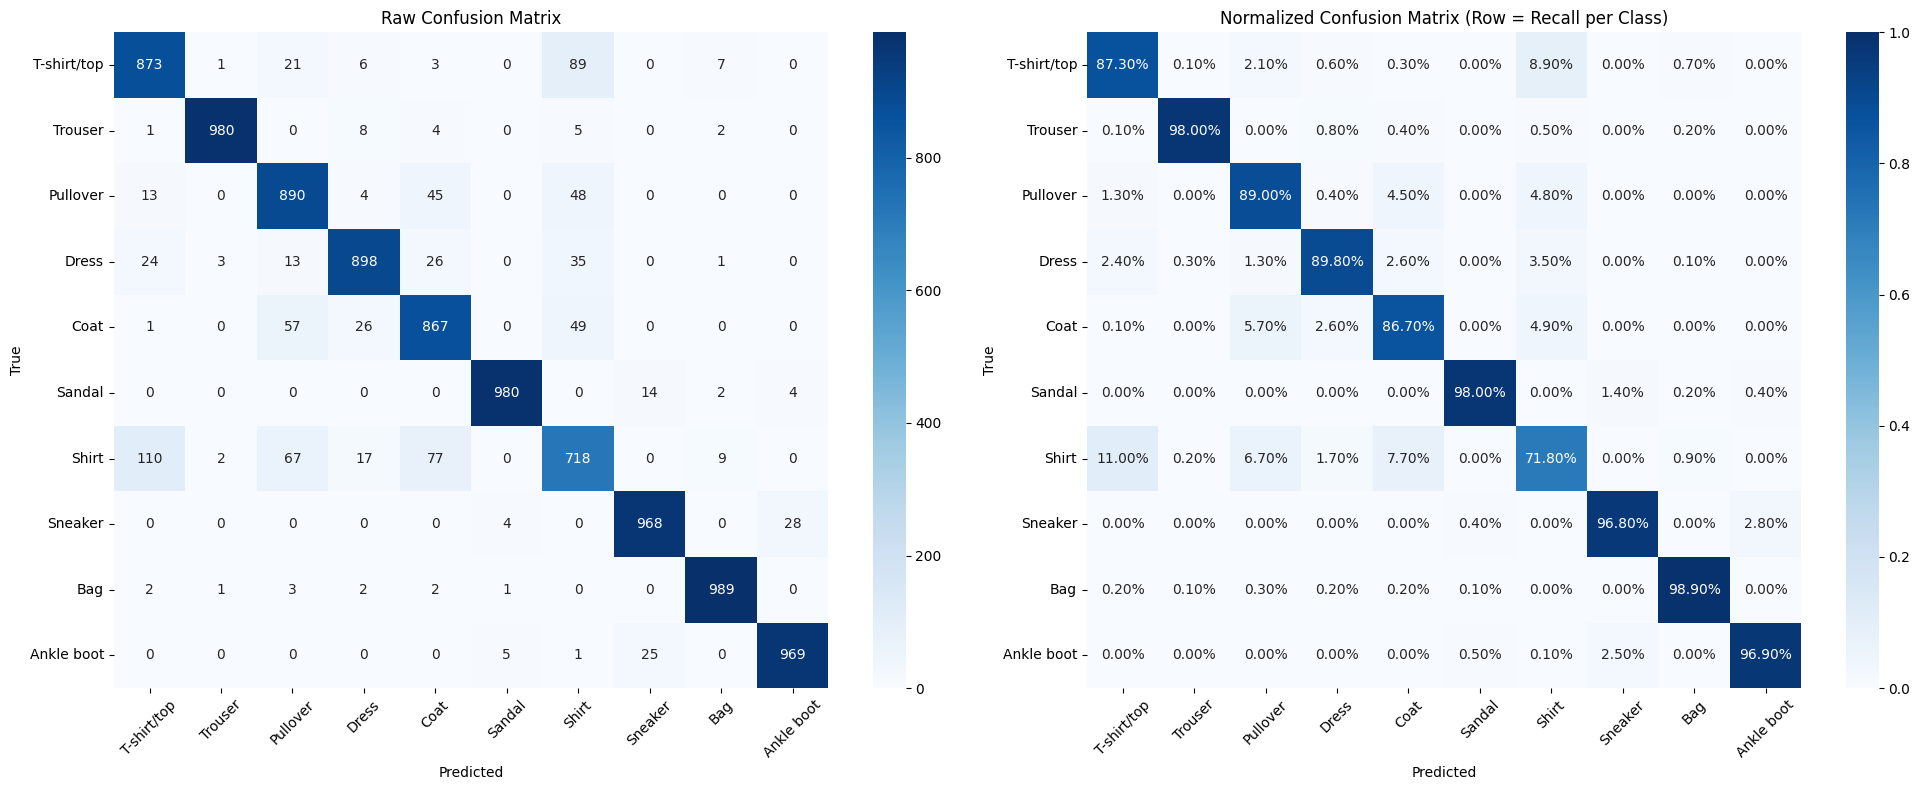


Expected Calibration Error (ECE): 0.0086
(Lower is better — 0 means perfectly calibrated)


In [18]:
# Comprehensive metric analysis
from sklearn.metrics import precision_recall_fscore_support

print("=" * 60)
print("COMPREHENSIVE METRIC ANALYSIS - CNN-ReLU")
print("=" * 60)

# Load best CNN-ReLU
best_model = CNN(nn.ReLU).to(device)
best_model.load_state_dict(torch.load('best_CNN_ReLU.pth'))
best_model.eval()

# Get predictions and probabilities
all_probs = []
all_true = []
with torch.no_grad():
    for x, y in test_loader:
        x = x.to(device)
        probs = torch.softmax(best_model(x), dim=1).cpu()
        all_probs.append(probs)
        all_true.append(y)
all_probs = torch.cat(all_probs).numpy()
all_true = torch.cat(all_true).numpy()
all_pred = all_probs.argmax(axis=1)

# Top-1 accuracy
top1_acc = (all_pred == all_true).mean()
print(f"\nTop-1 accuracy: {top1_acc:.4f}")

# Top-3 accuracy
top3_pred = np.argsort(all_probs, axis=1)[:, -3:]
top3_correct = np.array([true in top3_pred[i] for i, true in enumerate(all_true)])
top3_acc = top3_correct.mean()
print(f"Top-3 accuracy: {top3_acc:.4f}")

# Macro & weighted averages
precision_macro, recall_macro, f1_macro, _ = precision_recall_fscore_support(
    all_true, all_pred, average='macro')
precision_weighted, recall_weighted, f1_weighted, _ = precision_recall_fscore_support(
    all_true, all_pred, average='weighted')

print(f"\nMacro averages:    P={precision_macro:.4f}, R={recall_macro:.4f}, F1={f1_macro:.4f}")
print(f"Weighted averages: P={precision_weighted:.4f}, R={recall_weighted:.4f}, F1={f1_weighted:.4f}")

# Normalized confusion matrix (row-normalized = recall per class)
cm = confusion_matrix(all_true, all_pred)
cm_normalized = cm.astype('float') / cm.sum(axis=1, keepdims=True)

fig, axes = plt.subplots(1, 2, figsize=(20, 8))

# Raw confusion matrix
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=CLASSES, yticklabels=CLASSES,
            ax=axes[0], cbar=True)
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('True')
axes[0].set_title('Raw Confusion Matrix')
axes[0].tick_params(axis='x', rotation=45)
axes[0].tick_params(axis='y', rotation=0)

# Normalized confusion matrix
sns.heatmap(cm_normalized, annot=True, fmt='.2%', cmap='Blues',
            xticklabels=CLASSES, yticklabels=CLASSES,
            ax=axes[1], cbar=True, vmin=0, vmax=1)
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('True')
axes[1].set_title('Normalized Confusion Matrix (Row = Recall per Class)')
axes[1].tick_params(axis='x', rotation=45)
axes[1].tick_params(axis='y', rotation=0)

plt.tight_layout()
plt.savefig('confusion_matrix_detailed.png', dpi=150, bbox_inches='tight')
plt.show()

# Expected Calibration Error (ECE)
def expected_calibration_error(probs, labels, n_bins=10):
    """Compute ECE - lower is better calibrated."""
    confidences = probs.max(axis=1)
    predictions = probs.argmax(axis=1)
    accuracies = (predictions == labels).astype(float)

    bin_boundaries = np.linspace(0, 1, n_bins + 1)
    bin_lowers = bin_boundaries[:-1]
    bin_uppers = bin_boundaries[1:]

    ece = 0.0
    for bin_lower, bin_upper in zip(bin_lowers, bin_uppers):
        in_bin = (confidences > bin_lower) & (confidences <= bin_upper)
        if in_bin.sum() > 0:
            accuracy_in_bin = accuracies[in_bin].mean()
            confidence_in_bin = confidences[in_bin].mean()
            ece += (in_bin.sum() / len(confidences)) * abs(accuracy_in_bin - confidence_in_bin)
    return ece

ece = expected_calibration_error(all_probs, all_true)
print(f"\nExpected Calibration Error (ECE): {ece:.4f}")
print(f"(Lower is better — 0 means perfectly calibrated)")

LEARNING CURVE ANALYSIS


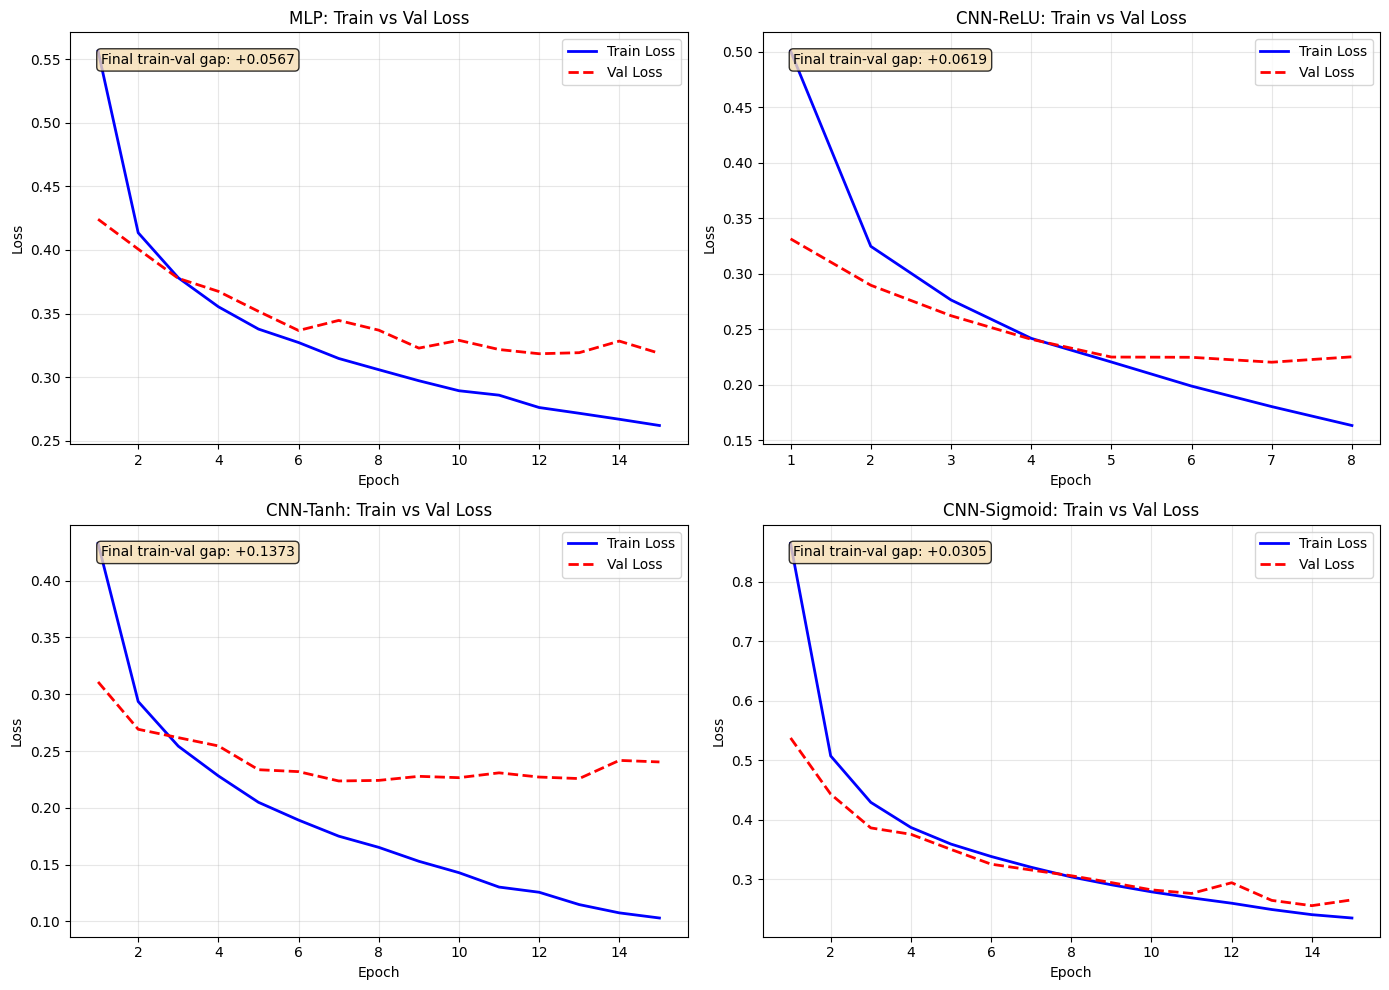


Train-Val Loss Gap Analysis (final epoch):
Model           Train Loss   Val Loss     Gap       
------------------------------------------------------------
MLP             0.2621      0.3188      +0.0567
CNN-ReLU        0.1633      0.2252      +0.0619
CNN-Tanh        0.1031      0.2404      +0.1373
CNN-Sigmoid     0.2346      0.2651      +0.0305


In [19]:
# Train vs Validation curves analysis (overfitting visualization)
print("=" * 60)
print("LEARNING CURVE ANALYSIS")
print("=" * 60)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

models_to_plot = ['MLP', 'CNN-ReLU', 'CNN-Tanh', 'CNN-Sigmoid']
for idx, name in enumerate(models_to_plot):
    ax = axes[idx // 2, idx % 2]
    h = results[name]['history']
    epochs_range = range(1, len(h['train_loss']) + 1)

    ax.plot(epochs_range, h['train_loss'], 'b-', label='Train Loss', linewidth=2)
    ax.plot(epochs_range, h['val_loss'], 'r--', label='Val Loss', linewidth=2)
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Loss')
    ax.set_title(f'{name}: Train vs Val Loss')
    ax.legend()
    ax.grid(alpha=0.3)

    # Annotate gap at final epoch
    final_gap = h['val_loss'][-1] - h['train_loss'][-1]
    ax.text(0.05, 0.95, f'Final train-val gap: {final_gap:+.4f}',
            transform=ax.transAxes, fontsize=10,
            verticalalignment='top',
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))

plt.tight_layout()
plt.savefig('train_val_curves.png', dpi=150, bbox_inches='tight')
plt.show()

# Print gap analysis
print("\nTrain-Val Loss Gap Analysis (final epoch):")
print(f"{'Model':<15} {'Train Loss':<12} {'Val Loss':<12} {'Gap':<10}")
print("-" * 60)
for name in models_to_plot:
    h = results[name]['history']
    train = h['train_loss'][-1]
    val = h['val_loss'][-1]
    print(f"{name:<15} {train:.4f}      {val:.4f}      {val-train:+.4f}")

In [20]:
# Save all results to a single file for the report
import json

all_experiment_results = {
    'baseline_models': {
        name: {
            'val_acc': r['best_acc'],
            'test_acc': test_results.get(name, None),
            'training_time': r['time']
        } for name, r in results.items()
    },
    'reproducibility': {
        'seeds_tested': list(seed_results.keys()),
        'val_accs': {str(k): v['val_acc'] for k, v in seed_results.items()},
        'test_accs': {str(k): v['test_acc'] for k, v in seed_results.items()},
        'val_mean': float(np.mean([r['val_acc'] for r in seed_results.values()])),
        'val_std': float(np.std([r['val_acc'] for r in seed_results.values()])),
        'test_mean': float(np.mean([r['test_acc'] for r in seed_results.values()])),
        'test_std': float(np.std([r['test_acc'] for r in seed_results.values()])),
    },
    'augmentation': {
        'val_acc_with_aug': float(best_val_acc_aug),
        'test_acc_with_aug': float(test_acc_aug),
        'val_acc_baseline': float(results['CNN-ReLU']['best_acc']),
        'delta_val': float(best_val_acc_aug - results['CNN-ReLU']['best_acc']),
    },
    'lr_sweep': {str(lr): r['best_val_acc'] for lr, r in lr_results.items()},
    'dropout_sweep': {str(dp): {
        'best_val_acc': r['best_val_acc'],
        'gap': r['gap']
    } for dp, r in dropout_results.items()},
    'optimizer_comparison': {name: r['best_val_acc'] for name, r in optimizer_results.items()},
    'ablation_study': {name: {
        'val_acc': r['best_val_acc'],
        'delta': r['delta']
    } for name, r in ablation_results.items()},
    'comprehensive_metrics': {
        'top1_acc': float(top1_acc),
        'top3_acc': float(top3_acc),
        'precision_macro': float(precision_macro),
        'recall_macro': float(recall_macro),
        'f1_macro': float(f1_macro),
        'ece': float(ece),
    }
}

with open('experiment_results.json', 'w') as f:
    json.dump(all_experiment_results, f, indent=2)

print("Results saved to experiment_results.json")
print("\n--- KEY FINDINGS FOR REPORT ---\n")
print(f"1. CNN-ReLU validation: {all_experiment_results['reproducibility']['val_mean']:.4f} ± {all_experiment_results['reproducibility']['val_std']:.4f} (3 seeds)")
print(f"2. CNN-ReLU test: {all_experiment_results['reproducibility']['test_mean']:.4f} ± {all_experiment_results['reproducibility']['test_std']:.4f}")
print(f"3. Augmentation: {all_experiment_results['augmentation']['delta_val']:+.4f} val acc change")
print(f"4. Top-3 accuracy: {top3_acc:.4f}")
print(f"5. ECE (calibration): {ece:.4f}")
print(f"6. Best optimizer: {max(optimizer_results, key=lambda k: optimizer_results[k]['best_val_acc'])}")
print(f"7. Worst ablation: {min(ablation_results, key=lambda k: ablation_results[k]['delta'])}")

# Download everything
from google.colab import files
files_to_download = [
    'preprocessing_analysis.png',
    'confusion_matrix_detailed.png',
    'train_val_curves.png',
    'experiment_results.json',
    'best_CNN_ReLU_aug.pth',
]
for f in files_to_download:
    if os.path.exists(f):
        files.download(f)
        print(f"Downloaded: {f}")

Results saved to experiment_results.json

--- KEY FINDINGS FOR REPORT ---

1. CNN-ReLU validation: 0.9257 ± 0.0027 (3 seeds)
2. CNN-ReLU test: 0.9181 ± 0.0017
3. Augmentation: -0.0013 val acc change
4. Top-3 accuracy: 0.9927
5. ECE (calibration): 0.0086
6. Best optimizer: Adam
7. Worst ablation: Single Conv block


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Downloaded: preprocessing_analysis.png


<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

Downloaded: experiment_results.json


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Downloaded: best_CNN_ReLU_aug.pth
